
Model Performance: 0.9533

Number of Polynomial Features: 10
Intercept: 5.1509


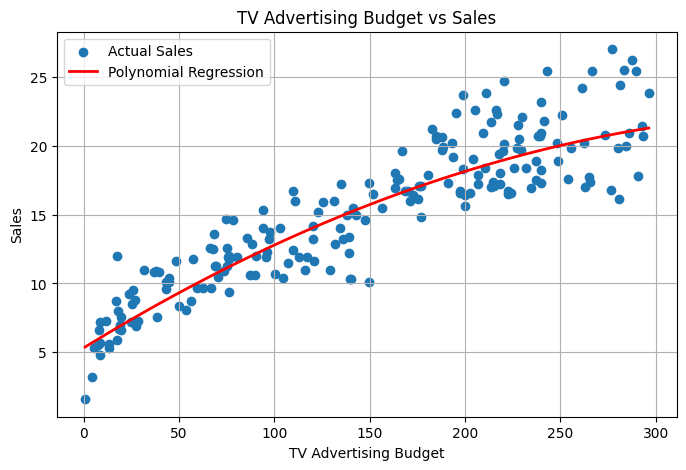

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("advertising.csv")

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\nModel Performance:",round(r2_score(y_test, y_pred), 4))

# Model Information
print("\nNumber of Polynomial Features:", X_poly.shape[1])
print("Intercept:", round(model.intercept_, 4))

tv_range = np.linspace(df['TV'].min(), df['TV'].max(), 100)

data = pd.DataFrame({
    'TV': tv_range,
    'Radio': df['Radio'].mean(),
    'Newspaper': df['Newspaper'].mean()
})

predicted_sales = model.predict(poly.transform(data))

plt.figure(figsize=(8, 5))
plt.scatter(df['TV'], y, label="Actual Sales")
plt.plot(tv_range, predicted_sales, linewidth=2, label="Polynomial Regression",color = "red")

plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV Advertising Budget vs Sales")
plt.legend()
plt.grid(True)
plt.show()



In [23]:
# Prediction
tv = float(input("Enter TV Advertising Budget: "))
radio = float(input("Enter Radio Advertising Budget: "))
newspaper = float(input("Enter Newspaper Advertising Budget: "))

new_budget = pd.DataFrame({
    'TV': [tv],
    'Radio': [radio],
    'Newspaper': [newspaper]
})

new_budget_poly = poly.transform(new_budget)
predicted_sales = model.predict(new_budget_poly)

print("\nAdvertising Budget:")
print(new_budget)

print("Predicted Sales:", round(predicted_sales[0], 2))

Enter TV Advertising Budget: 57.5
Enter Radio Advertising Budget: 32.8
Enter Newspaper Advertising Budget: 23.5

Advertising Budget:
     TV  Radio  Newspaper
0  57.5   32.8       23.5
Predicted Sales: 10.58
